In [60]:
# import basic libraries
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pylab as plt

# import machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.pipeline import make_pipeline 
from imblearn.pipeline import make_pipeline as imb_make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.inspection import permutation_importance


# import necessary functions and options
import sys
import os

sys.path.append(os.path.abspath('..'))
import my_utils as mu

from sklearn import set_config

set_config(transform_output = 'pandas')


In [61]:
# import the dataset 
df = pd.read_csv('adult-income.csv')

# run the head()
df.head()

,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


In [62]:
# check the info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   age              48842 non-null  int64
 1   workclass        48842 non-null  str  
 2   fnlwgt           48842 non-null  int64
 3   education        48842 non-null  str  
 4   educational-num  48842 non-null  int64
 5   marital-status   48842 non-null  str  
 6   occupation       48842 non-null  str  
 7   relationship     48842 non-null  str  
 8   race             48842 non-null  str  
 9   gender           48842 non-null  str  
 10  capital-gain     48842 non-null  int64
 11  capital-loss     48842 non-null  int64
 12  hours-per-week   48842 non-null  int64
 13  native-country   48842 non-null  str  
 14  income           48842 non-null  str  
dtypes: int64(6), str(9)
memory usage: 5.6 MB


# Simple `EDA` analysis 

In [63]:
# check null values
df.isnull().sum().sum()

np.int64(0)

In [64]:
# check the duplicates
df.duplicated().sum()

np.int64(52)

In [65]:
# remove the duplicates
df = df.drop_duplicates()

# check the duplicates again
df.duplicated().sum()

np.int64(0)

In [66]:
# find ? rows 
# Check for '?' in each column
(df == '?').sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

In [67]:
# replace ? with NaN
df = df.replace('?', np.nan)

# check for null values 
df.isna().sum()

age                   0
workclass          2795
fnlwgt                0
education             0
educational-num       0
marital-status        0
occupation         2805
relationship          0
race                  0
gender                0
capital-gain          0
capital-loss          0
hours-per-week        0
native-country      856
income                0
dtype: int64

# Inspect every **`column`**

In [68]:
# check the age column 
mu.profile_column(df, 'age', show_value_counts = False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,74 — High
Skewness,0.556582


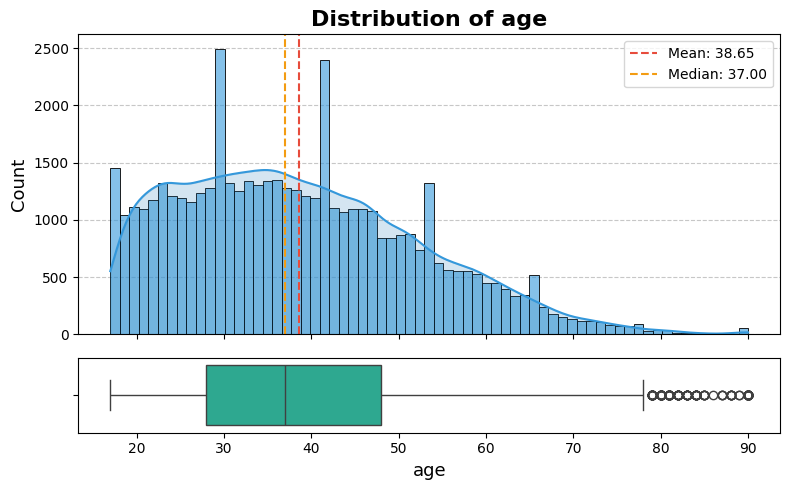

In [69]:
# plot univariate analysis for age'
mu.plot_univariate_analysis(df, 'age', figsize = (8, 5), bins = 67)


In [70]:
# check the workclass column
mu.profile_column(df, 'workclass')


,Value
Data Type,str
Null Count,2795
Null %,5.7%
Constant/Quasi,Neither
Cardinality,8 — Low
Skewness,N/A
,count
workclass,
Private,33860
Self-emp-not-inc,3861


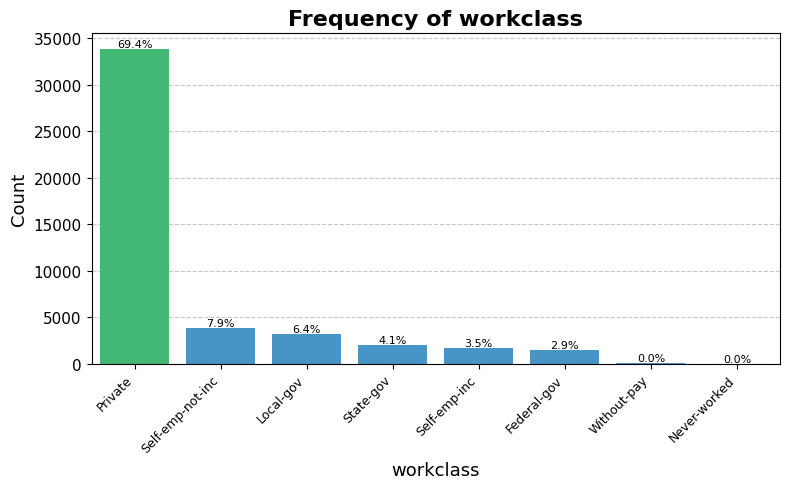

In [71]:
# plot univariate analysis for workclass 
mu.plot_univariate_analysis(df, 'workclass', figsize = (8, 5))

---

In [72]:
# check the education column
mu.profile_column(df, 'education')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,16 — Medium
Skewness,N/A
,count
education,
HS-grad,15770
Some-college,10863


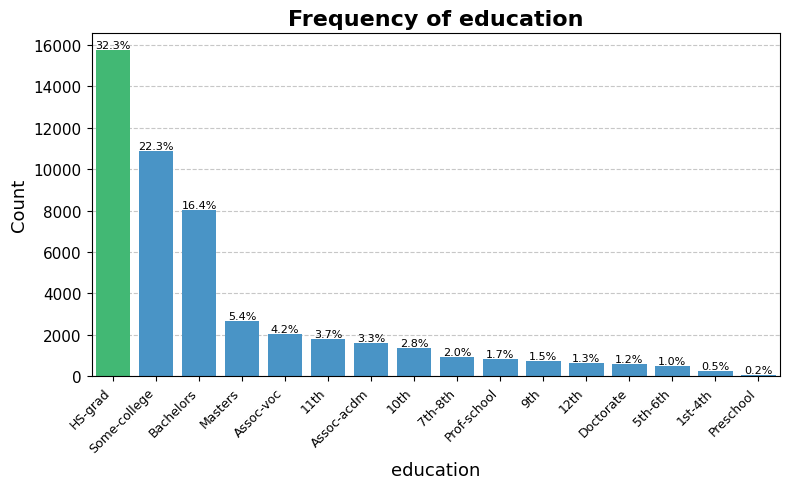

In [73]:
# plot univariate analysis for educatoin 
mu.plot_univariate_analysis(df, 'education', figsize = (8, 5))

---

In [74]:
# check the fnlwgt column 
mu.profile_column(df, 'fnlwgt', show_value_counts = False)


,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,28523 — High
Skewness,1.439698


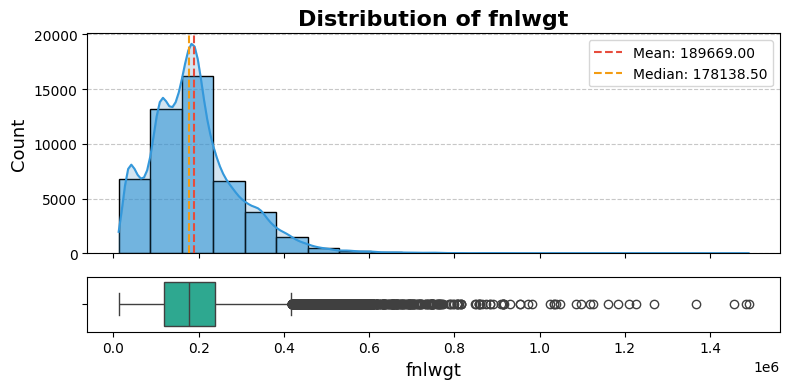

In [75]:
# plot univariate analysis for fnlwgt 
mu.plot_univariate_analysis(df, 'fnlwgt')

In [76]:
# check the educational-num column
mu.profile_column(df, 'educational-num', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,16 — Medium
Skewness,-0.314229


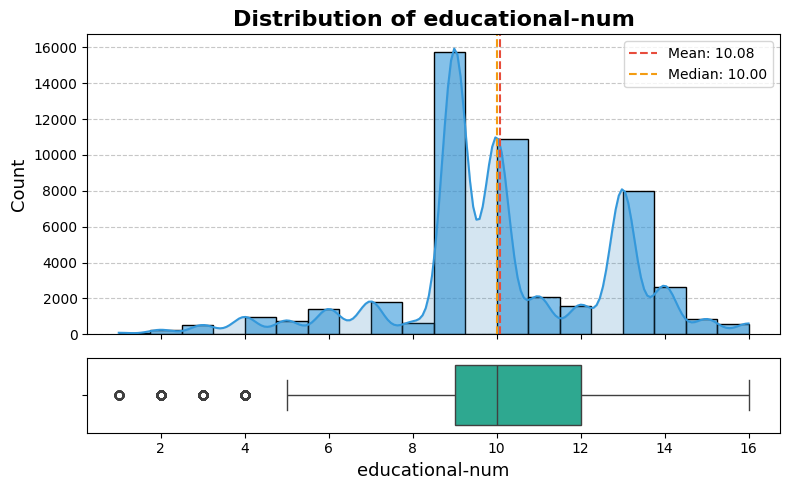

In [77]:
# plot univariate analysis for educational-num
mu.plot_univariate_analysis(df, 'educational-num', figsize=(8, 5))

In [78]:
# check the marital-status column
mu.profile_column(df, 'marital-status')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,7 — Low
Skewness,N/A
,count
marital-status,
Married-civ-spouse,22366
Never-married,16082


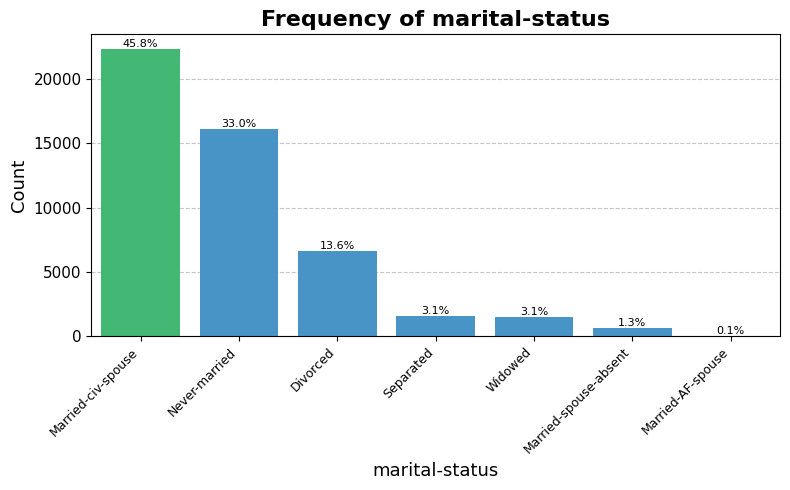

In [79]:
# plot univariate analysis for marital-status
mu.plot_univariate_analysis(df, 'marital-status', figsize=(8, 5))

In [80]:
# check the occupation column
mu.profile_column(df, 'occupation')

,Value
Data Type,str
Null Count,2805
Null %,5.7%
Constant/Quasi,Neither
Cardinality,14 — Medium
Skewness,N/A
,count
occupation,
Prof-specialty,6165
Craft-repair,6102


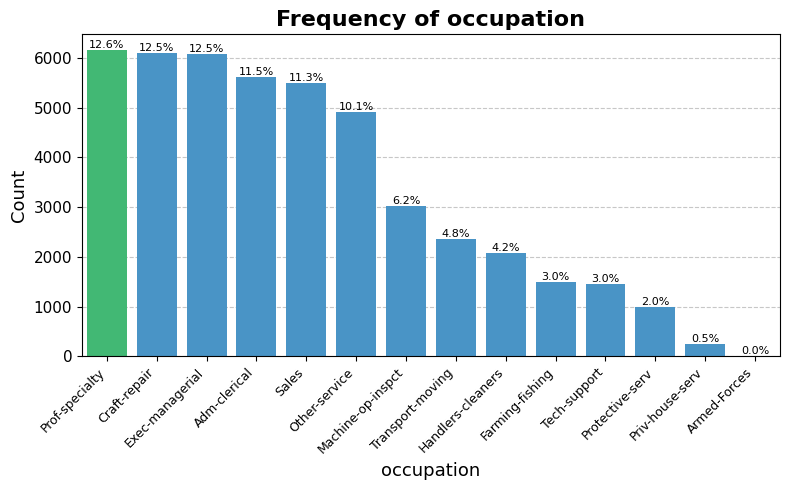

In [81]:
# plot univariate analysis for occupation
mu.plot_univariate_analysis(df, 'occupation', figsize=(8, 5))

In [82]:
# check the relationship column
mu.profile_column(df, 'relationship')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,6 — Low
Skewness,N/A
,count
relationship,
Husband,19703
Not-in-family,12557


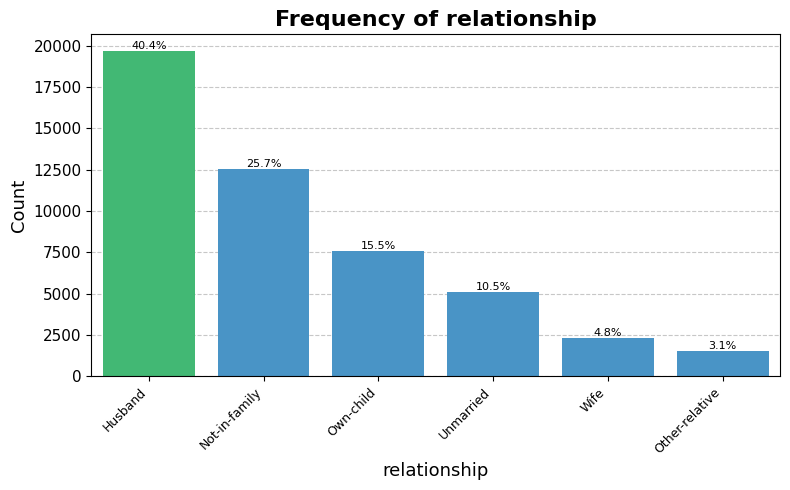

In [83]:
# plot univariate analysis for relationship
mu.plot_univariate_analysis(df, 'relationship', figsize=(8, 5))

In [84]:
# check the race column
mu.profile_column(df, 'race')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,5 — Low
Skewness,N/A
,count
race,
White,41714
Black,4683


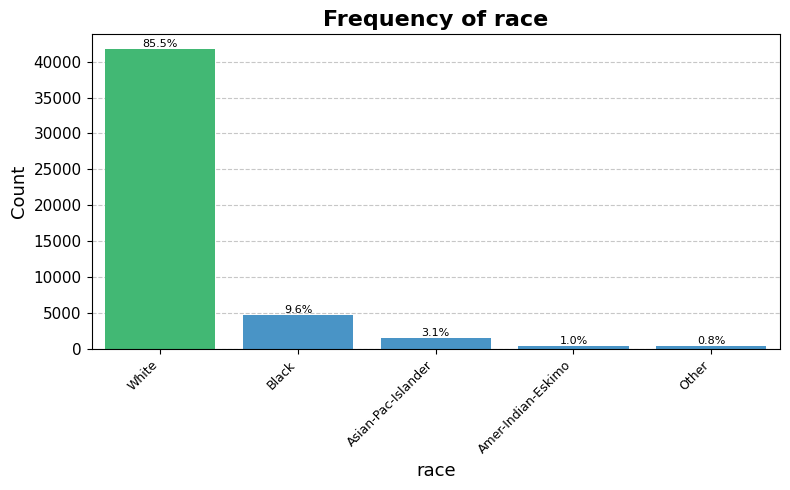

In [85]:
# plot univariate analysis for race
mu.plot_univariate_analysis(df, 'race', figsize=(8, 5))

In [86]:
# check the gender column
mu.profile_column(df, 'gender')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,N/A
,count
gender,
Male,32614
Female,16176


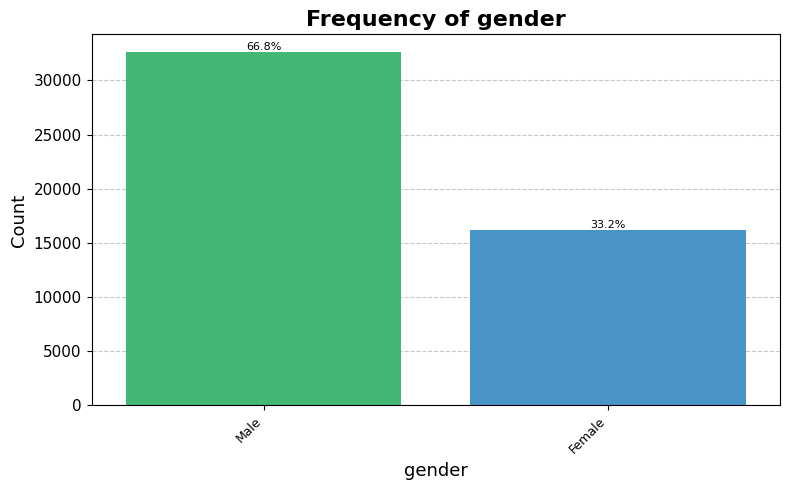

In [87]:
# plot univariate analysis for gender
mu.plot_univariate_analysis(df, 'gender', figsize=(8, 5))

In [88]:
# check the capital-gain column
mu.profile_column(df, 'capital-gain', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,123 — High
Skewness,11.888265


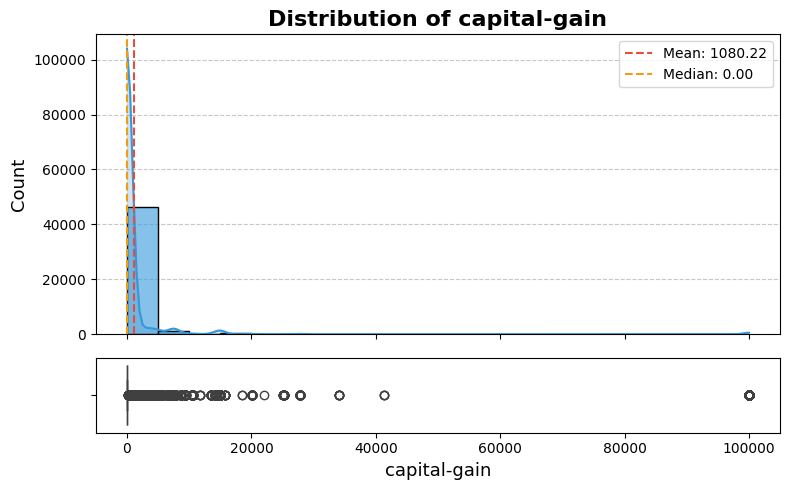

In [89]:
# plot univariate analysis for capital-gain
mu.plot_univariate_analysis(df, 'capital-gain', figsize=(8, 5))

In [90]:
# check the capital-loss column
mu.profile_column(df, 'capital-loss', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Quasi-constant
Cardinality,99 — High
Skewness,4.567037


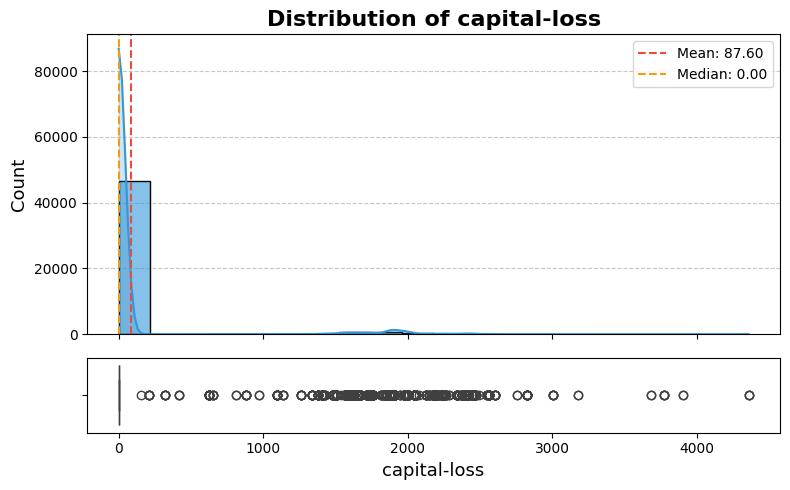

In [91]:
# plot univariate analysis for capital-loss
mu.plot_univariate_analysis(df, 'capital-loss', figsize=(8, 5))

In [92]:
# check the hours-per-week column
mu.profile_column(df, 'hours-per-week', show_value_counts=False)

,Value
Data Type,int64
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,96 — High
Skewness,0.239652


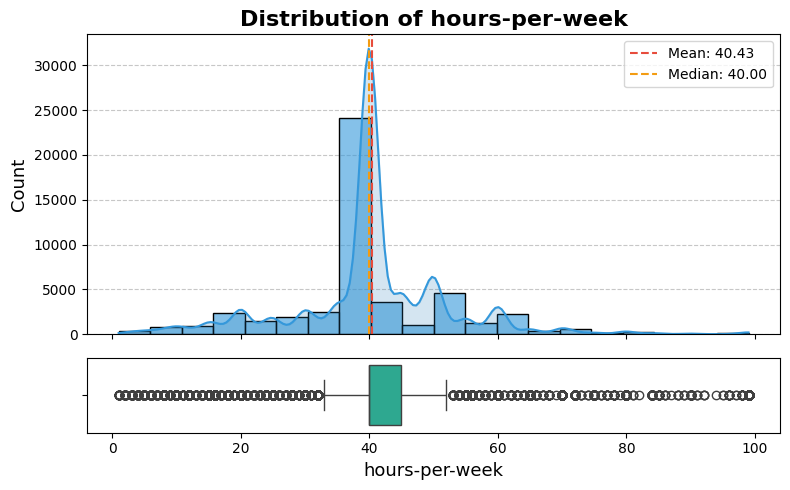

In [93]:
# plot univariate analysis for hours-per-week
mu.plot_univariate_analysis(df, 'hours-per-week', figsize=(8, 5))

In [94]:
# check the native-country column
mu.profile_column(df, 'native-country', show_value_counts = False)

,Value
Data Type,str
Null Count,856
Null %,1.8%
Constant/Quasi,Neither
Cardinality,41 — Medium
Skewness,N/A


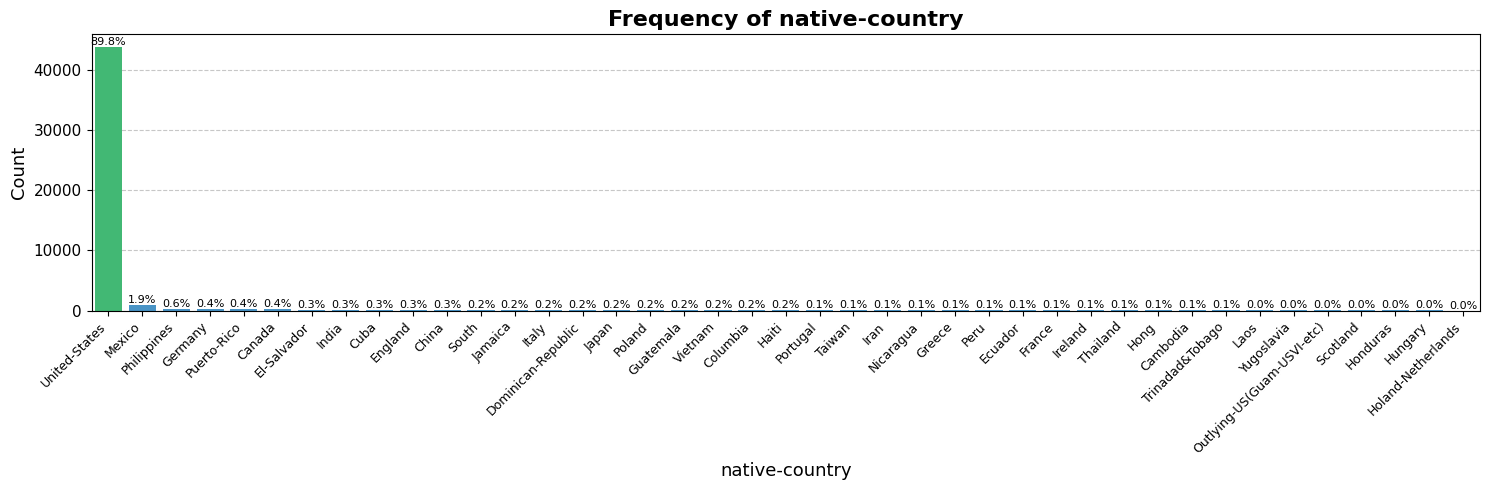

In [95]:
# plot univariate analysis for native-country
mu.plot_univariate_analysis(df, 'native-country', figsize=(15, 5))

In [96]:
# check the income column
mu.profile_column(df, 'income')

,Value
Data Type,str
Null Count,0
Null %,0.0%
Constant/Quasi,Neither
Cardinality,2 — Low
Skewness,N/A
,count
income,
<=50K,37109
>50K,11681


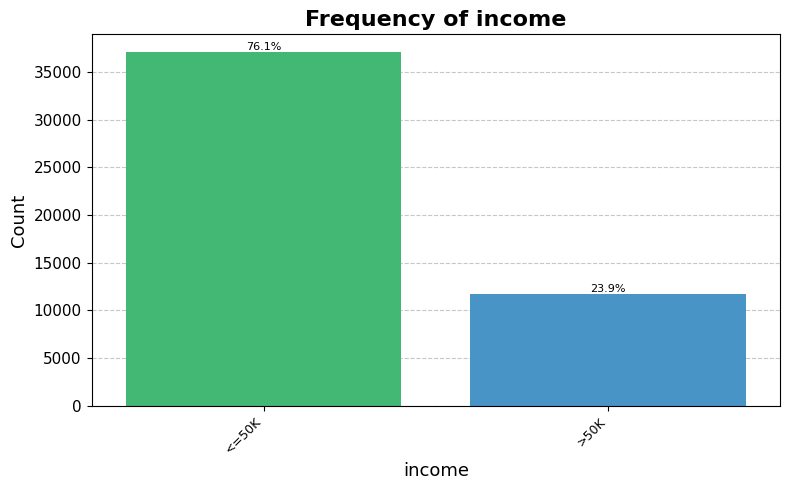

In [97]:
# plot univariate analysis for income
mu.plot_univariate_analysis(df, 'income', figsize=(8, 5))

# Dataset Assessment

## 1. Outliers — `hours-per-week` is the real problem

| Column | Outliers |
|---|---|
| `hours-per-week` | **27.6%** — severe, not just a few edge cases |
| `capital-gain` | 8.3% |
| `capital-loss` | 4.7% |
| `educational-num` | 3.7% |
| `fnlwgt` | 3.0% |
| `age` | 0.4% — negligible |

`capital-gain` and `capital-loss` are especially tricky because **most values are 0** and a small number are very high — that's a structural skew, not just noise. Consider creating a single `net-capital` feature or a binary flag instead.

---

## 2. The `?` Values Are Actually Missing Data in Disguise

| Column | `?` count | % |
|---|---|---|
| `workclass` | 2,795 | 5.7% |
| `occupation` | 2,805 | 5.7% |
| `native-country` | 856 | 1.8% |

The `workclass` and `occupation` counts are nearly identical — likely **the same rows**, meaning ~5.7% of the dataset has two columns missing simultaneously. Options: impute with the mode, or create an `"Unknown"` category.

---

## 3. Target Imbalance — Moderate but Needs Handling

- `<=50K`: **76.1%**
- `>50K`: **23.9%** → roughly a **3.2:1 ratio**

Not catastrophic, but enough to skew a model toward the majority class. Options: `class_weight='balanced'`, SMOTE oversampling, or threshold tuning.

---

## 4. Feature Engineering — Columns That Need Attention

| Column | Unique | Issue |
|---|---|---|
| `native-country` | **42** | Most rows are `United-States`. Group into continents or binary US/non-US |
| `education` | 16 | **Redundant** — `educational-num` is its ordinal encoding. Drop one |
| `marital-status` | 7 | Can be simplified to `married` / `not-married` |
| `occupation` | 15 | Borderline — could group related jobs or leave as-is for tree models |

---

## Bonus: `fnlwgt` Should Be Dropped

`fnlwgt` (census sampling weight) has **no predictive value** for income — it's a statistical artifact, not a personal attribute.

---

# `Feature Engineering`: 

In [98]:
# log transformation for capital-gain and loss (log1p handles zeros safely)
df['capital-gain'] = np.log1p(df['capital-gain'])
df['capital-loss'] = np.log1p(df['capital-loss'])



In [99]:
# binary flag for capital-loss and gain
# df['capital-loss'] = (df['capital-loss'] > 0).astype(int)
# df['capital-gain'] = (df['capital-gain'] > 0).astype(int)


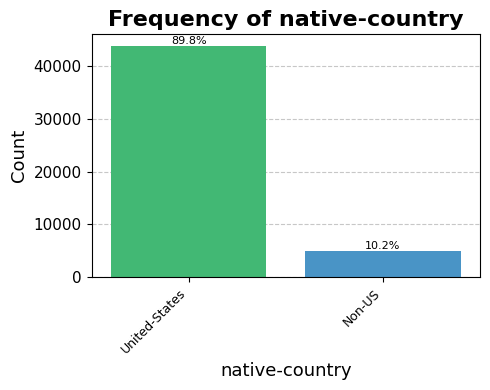

In [100]:
# categorize native countries into US and Non-US
df['native-country'] = df['native-country'].apply(lambda x: x if x == 'United-States' else 'Non-US')

# run the a plot to view native-country column
mu.plot_univariate_analysis(df, 'native-country', figsize = (5, 4))

In [101]:
# drop fnlwgt and education columns 
df = df.drop(columns = ['fnlwgt', 'education'])

# run the dataframe after the modification
df.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0.000000,0.0,40,United-States,<=50K
1,38,Private,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0.000000,0.0,50,United-States,<=50K
2,28,Local-gov,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0.000000,0.0,40,United-States,>50K
3,44,Private,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,8.947546,0.0,40,United-States,>50K
4,18,NaN,10,Never-married,NaN,Own-child,White,Female,0.000000,0.0,30,United-States,<=50K


In [102]:
# use this code for KNN, LogesticRegression or neural networks
# df['hours-per-week'] = df['hours-per-week'].clip(upper=80)

# Preprocessing the dataset

In [103]:
# save the target
y = df['income']

# save the features 
X = df.drop(columns = 'income')

# run train test split on the dataset 
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 43, stratify=y)

# run X_train.head()
X_train.head()

,age,workclass,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country
16321,31,Private,5,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0.000000,0.0,43,United-States
10014,35,Private,13,Married-civ-spouse,Sales,Husband,White,Male,0.000000,0.0,42,United-States
36477,40,Self-emp-inc,12,Divorced,Sales,Unmarried,White,Female,7.317876,0.0,40,United-States
5586,43,Private,10,Never-married,Other-service,Not-in-family,White,Female,0.000000,0.0,40,United-States
20875,23,Private,12,Never-married,Other-service,Own-child,White,Male,0.000000,0.0,60,United-States


# Preprocess: `Numerical Cols` for distance-based models

In [104]:
# num_cols 
num_cols = X_train.select_dtypes('number').columns
num_cols

# imputing
num_imputer = SimpleImputer(strategy = 'median')
num_imputer

# scaling 
num_scaler = StandardScaler()
num_scaler

# num_pipe
num_pipe = make_pipeline(num_imputer, num_scaler)
num_pipe

# num_tuple 
num_tuple = ('Numerical cols', num_pipe, num_cols)
num_tuple

('Numerical cols',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='median')),
                 ('standardscaler', StandardScaler())]),
 Index(['age', 'educational-num', 'capital-gain', 'capital-loss',
        'hours-per-week'],
       dtype='str'))

# Preprocess: `Categorical Cols` for distance-based models 

In [105]:
# categorical cols
cat_cols = X_train.select_dtypes(include=['str']).columns
cat_cols

# cat_imputer 
cat_imputer = SimpleImputer(strategy = 'most_frequent')
cat_imputer

# cat_encoder
cat_encoder = OneHotEncoder(handle_unknown = 'ignore', sparse_output = False)
cat_encoder

# cat_pipe
cat_pipe = make_pipeline(cat_imputer, cat_encoder)
cat_pipe

# cat_tuple
cat_tuple = ('Categorical cols', cat_pipe, cat_cols)
cat_tuple

('Categorical cols',
 Pipeline(steps=[('simpleimputer', SimpleImputer(strategy='most_frequent')),
                 ('onehotencoder',
                  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
 Index(['workclass', 'marital-status', 'occupation', 'relationship', 'race',
        'gender', 'native-country'],
       dtype='str'))

In [106]:
col_transformer = ColumnTransformer([num_tuple, cat_tuple], verbose_feature_names_out = False)
col_transformer

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('Numerical cols', ...), ('Categorical cols', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and 

# Initiate and fit `LogisticRegression model`

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90     27831
        >50K       0.72      0.59      0.64      8761

    accuracy                           0.85     36592
   macro avg       0.80      0.76      0.77     36592
weighted avg       0.84      0.85      0.84     36592



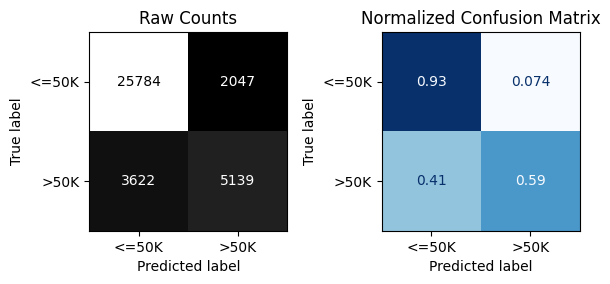


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.90      9278
        >50K       0.71      0.58      0.64      2920

    accuracy                           0.84     12198
   macro avg       0.79      0.75      0.77     12198
weighted avg       0.84      0.84      0.84     12198



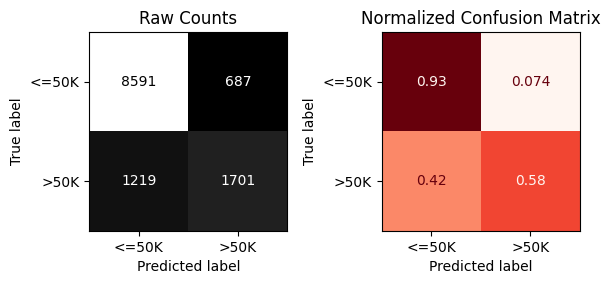

In [107]:
# intiate the model 
lr_model = LogisticRegression(random_state=43, max_iter=1000)

# create pipeline
lr_pipeline = make_pipeline(col_transformer, lr_model)

# fit the model 
lr_pipeline.fit(X_train, y_train)

# show the results
mu.evaluate_classification(lr_pipeline, X_train, y_train, X_test, y_test)


# **Tree-based models**

In [108]:
# tree-based column transformer
tree_col_transformer = ColumnTransformer(transformers=[
    ('Numerical', SimpleImputer(strategy='median'), X_train.select_dtypes('number').columns),
    ('Categorical', make_pipeline(
        SimpleImputer(strategy='most_frequent'),
        OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    ), X_train.select_dtypes('str').columns)
], verbose_feature_names_out=False)

# Initiate and fit `RandomForest model`

----------------------------------------------------------------------
 Classification Metrics: Training Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.98      0.99      0.98     27831
        >50K       0.96      0.93      0.95      8761

    accuracy                           0.97     36592
   macro avg       0.97      0.96      0.96     36592
weighted avg       0.97      0.97      0.97     36592



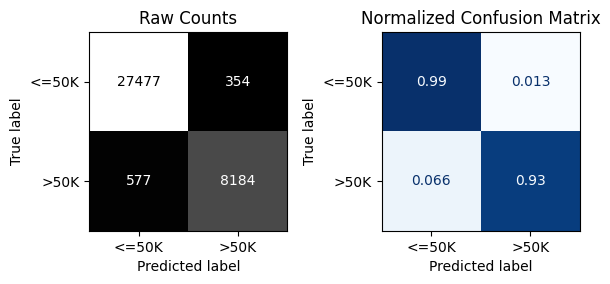


----------------------------------------------------------------------
 Classification Metrics: Test Data
----------------------------------------------------------------------
              precision    recall  f1-score   support

       <=50K       0.89      0.92      0.91      9278
        >50K       0.72      0.63      0.67      2920

    accuracy                           0.85     12198
   macro avg       0.81      0.78      0.79     12198
weighted avg       0.85      0.85      0.85     12198



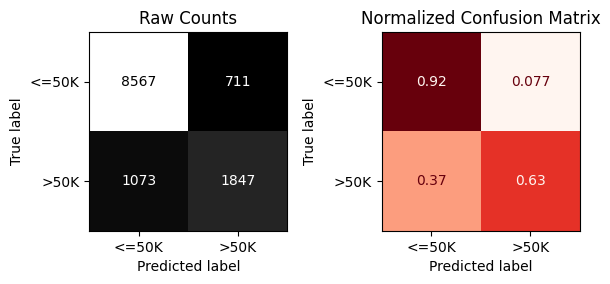

In [109]:
# initiate random forest model 
rf_model = RandomForestClassifier(random_state=43, n_jobs=-1)

# create a pipeline 
rf_pipeline = make_pipeline(tree_col_transformer, rf_model)

# Fit the model 
rf_pipeline.fit(X_train, y_train)

# show results of the model 
mu.evaluate_classification(rf_pipeline, X_train, y_train, X_test, y_test)

# Top 10 Features — Permutation Importance (Random Forest)

In [110]:
perm_result = permutation_importance(
    rf_pipeline, X_test, y_test,
    n_repeats=10, random_state=43, n_jobs=1
)

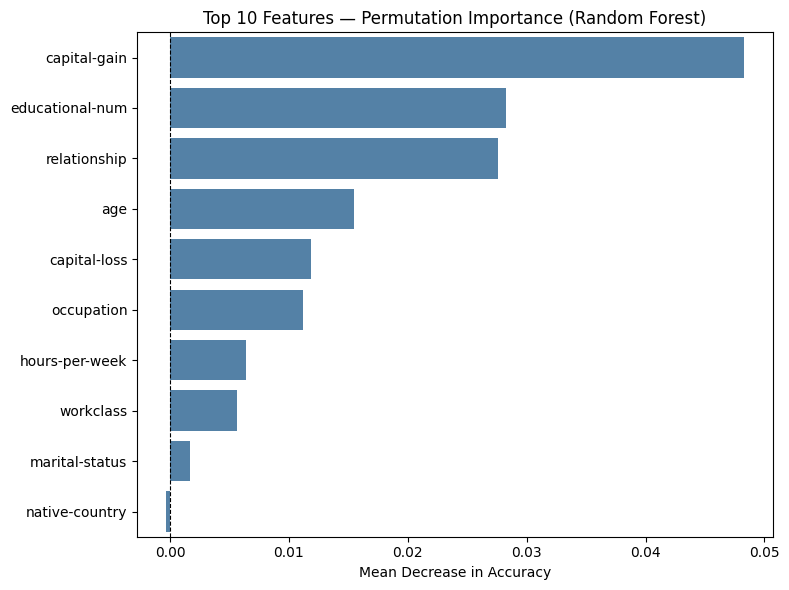

In [111]:
perm_df = pd.DataFrame({
    'feature':         X_test.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std':  perm_result.importances_std
}).sort_values('importance_mean', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8, 6))
sns.barplot(data=perm_df, x='importance_mean', y='feature', ax=ax, color='steelblue')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_ylabel('')
ax.set_title('Top 10 Features — Permutation Importance (Random Forest)')
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

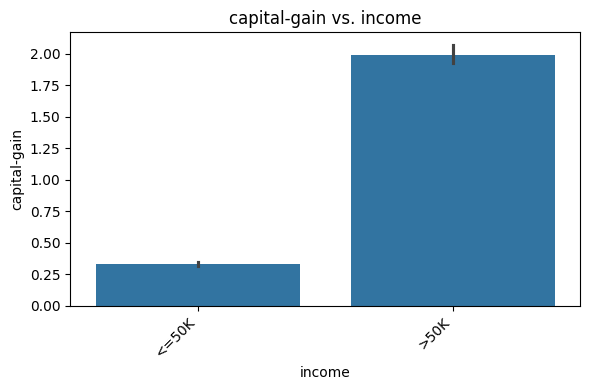

In [112]:
mu.plot_numeric_vs_categorical(df, 'capital-gain', 'income');

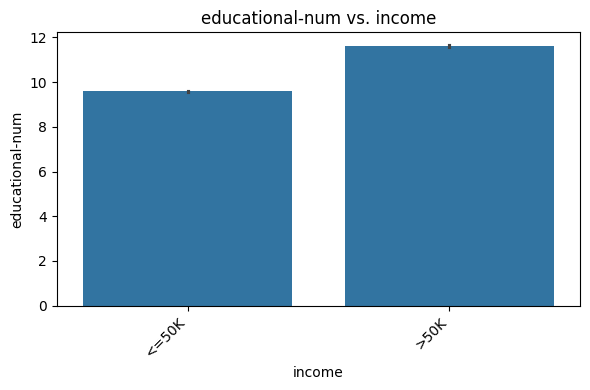

In [113]:
mu.plot_numeric_vs_categorical(df, 'educational-num', 'income');

## Do These Features Make Sense? — Business Case Observations

The permutation importance results align strongly with real-world intuition about income.

---

### 1. `capital-gain` — Strongest Predictor (importance: ~0.048)

People earning **>$50K** have an average capital-gain of **~2.0** (log-scaled),
compared to just **~0.3** for those earning ≤$50K — a 6x difference.

This makes complete sense: investment income (stocks, real estate) is
almost exclusively held by higher-income individuals. Having any capital
gain is itself a strong signal of financial wealth.

---

### 2. `educational-num` — Second Strongest (importance: ~0.029)

People earning **>$50K** average an education level of **~11.6**
(roughly an Associate's or Bachelor's degree), versus **~9.6** for
those earning ≤$50K (roughly a high school diploma).

This aligns with well-established economic research: higher education
unlocks higher-paying professions, higher starting salaries, and faster
career progression.

---

### Summary

Both features reflect structural, real-world drivers of income — not
statistical noise. A stakeholder would find these results immediately
intuitive: *people who invest and people who study longer tend to earn more.*